# MOD510: Project 4

**Deadline: 01. December 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1: Stochastic modeling of mixing tanks


## Part 1: Single Mixing Tank with Parameter Uncertainty 

### Task 1 - Derivation of the concentration in a single mixing tank

We concider a well-mixed tank with constant volume $V$, inflow rate $Q_{in}$, outflow rate $Q_{out}$ and constant inflow concentration $C_{in}$.

To determine the solute concentration in the tank, $C(t)$, the following governing differential equation must be solved: 


$$\frac{dC}{dt} = \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V} C.$$

The governing differential equation is a first-order linear ordinary differential equation of the form

$$\frac{dC}{dt} + P(t)C = Q(t),$$

with

$$P(t) = \frac{Q_{out}}{V}, \quad  \quad \quad Q(t) = \frac{Q_{in}}{V} C_{in},$$

where $P$ and $Q$ are constants, since the system parameters do not vary with time.

**Integrating factor**

The integrating factor of a first-order linear ODE is defined as

$$I(t) = e^{\int P(t) \text{ dt}}.$$

For readability, we will write the exponential function using the notation $\exp(\space)$:

$$I(t) = \exp\left(\int P(t) \text{ dt}\right).$$

Substituting $P(t) = \frac{Q_{out}}{V}$, we obtain

$$I(t) = \exp\left(\int \frac{Q_{out}}{V} \text{ dt}\right) \quad \Rightarrow \quad I(t) = \exp\left(\frac{Q_{out}}{V}t\right)$$

Using the integrating factor $I(t)$, the solution of the first-order linear ODE can be written as

$$C(t) = \frac{1}{I(t)}\left( \int I(t) Q(t) \text{ dt} + K\right),$$

where $K$ is an integration constant. 

Substituting 

$$I(t) = \exp\left(\frac{Q_{out}}{V}t\right), \quad \quad \quad Q(t) = \frac{Q_{in}}{V} C_{in},$$

gives

$$C(t) = \frac{1}{\exp\left(\frac{Q_{out}}{V}t\right)} \cdot \left( \int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} + K\right).$$

This can be rewritten as

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left( \int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} + K\right)$$

Evaluating the integral yields:

$$\int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} = \frac{V}{Q_{out}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} + K$$

Substituting back, we obtain

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left(\frac{V}{Q_{out}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} + K \right)$$

This simplifies to

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left(\exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{Q_{out}} C_{in} + K \right)$$

Multiplying through gives

$$C(t) = K\exp\left(-\frac{Q_{out}}{V}t\right) + \frac{Q_{in}}{Q_{out}} C_{in}$$

Finally, the solution is

$$\boxed{C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in} }$$

### Task 2 - Analytical solution with average parameters

Using the average parameter values

$$V = 1000 \text{ L} \quad Q_{out} = 100 \text{ L/s} \quad Q_{in} = 100 \text{ L/s} \quad C_{in} = 0.25 \text{ g/L} \quad C(0) = 3.5 \text{ g/L},$$

the general solution from Task $1$, 

$$C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in}$$

becomes

$$ C(t) =  K e^{- \frac{100 \text{ L/s}}{1000 \text{ L}} t} + \frac{100 \text{ L/s}}{100 \text{ L/s}} \cdot 0.25 \text{ g/L}. $$

Which simplifies to 

$$C(t) = K e^{-0.1 \text{ s}^{-1}t} + 0.25 \text{ g/L}$$

To find $K$, we apply the initial condition $C(0) = 3.5$ g/L:

$$K e^{0} + 0.25 \text{ g/L} = 3.5 \text{ g/L} \quad \Rightarrow \quad K = 3.5\text{ g/L} - 0.25 \text{ g/L} \quad \Rightarrow \quad K = 3.25\text{ g/L}$$

With $t$ measured in seconds, the concentration $C(t)$ in g/L is therefore

$$\boxed{C(t)= 3.25 \cdot e^{-0.1t} + 0.25}$$

The concentration decreases exponentially from the initial value $3.5$ g/L towards the steady-state value $0.25$ g/L. 

### Task 3 - Probabilistic interpretation of outflow

The probabilitiy that a gram of solute leaves the tank during a time interval $\Delta t$ is 

$$p = 1 - e^{-\frac{Q_{out}}{V} \Delta t}.$$

**Interpretation:**
\begin{align*}
1 - p = & \text{ probability that a gram of solute remains in the tank.}\\
p = & \text{ probability that a gram of solute leaves the tank.} 
\end{align*}


This gives the following update for the concentration:

$$\boxed{C(t + \Delta t) = (1 - p)C(t) + pC_{in}}$$

**Broken down:**
\begin{align*}
(1 - p)C(t) = & \text{ portion of the old concentration that remains in the tank.}\\
pC_{in} = & \text{ portion that is replaced by fresh inflow.} 
\end{align*}

This shows that the updated concentration depends on how much of the old solution remains and how much fresh solution enters, controlled by the probabillity of solute leaving during the time interval. 

### Task 4 - Monte Carlo Simulation with Fixed Parameters

For option $1$, all uncertain parameters are sampled once at the beginning of each run and remain fixed throughout the run. 

For each run, the concentration is updated over $1000$ time steps using the probailistic update rule from Task $3$, based on the probability that a gram of fluid leaves the tank during a timer interval $\Delta t$: 
$$p = 1 - e^{-\frac{Q_{out}}{V} \Delta t}.$$

The concentration is then updated as: 
$$C(t + \Delta t) = (1 - p)C(t) + pC_{in}$$

The simulation is carried out over a total time of $100$ s, meaning each time step corresponds to
$$\Delta t = \frac{100 \text{ s}}{1000} = 0.1 \text{ s}$$

To make the simulation structured and reusable, the Monte Carlo procedure is implemented as a function. This function allows switching between fixed parameters per run and parameters that vary at each time step through a Boolean input `fixed_parameters`, making it straightforward to compare the two modelling options. 

In [1]:
import numpy as np
from numpy import random as rnd

def monte_carlo_simulation(t0, tf, n_runs, n_steps, fixed_parameters):
    '''
    Monte Carlo simulation of concentration evolution in a mixing tank.

    Input
    ------
    t0: float
        Start time [s]
    tf: float
        Final time [s]
    n_runs: int
        Number of Monte Carlo runs
    n_steps: int
        Number of time steps per run
    fixed_parameters: bool
        If True, parameters are fixed per run.
        If False, parameters vary at each time step.

    Output
    ------
    c_mean: ndarray
        Mean concentration over runs
    c_std: ndarray
        Standard deviation over runs
    ci_lower: ndarray
        2.5th percentile
    ci_upper: ndarray
        97.5 percentile
    '''
    #For reproducibility
    rnd.seed(18)

    #Delta time
    dt = (tf - t0) / n_steps

    #Allocate concentration history
    concentration_history = np.zeros((n_runs, n_steps))

    #Monte Carlo simulation
    for run in range(n_runs):
        v = rnd.uniform(950, 1050)
        c = rnd.uniform(3.4, 3.6)

        if fixed_parameters:
            q_out = q_in = rnd.uniform(95, 105)
            c_in = 0.0

        for t in range(n_steps):
            if not fixed_parameters:
                q_out = q_in = rnd.uniform(95, 105)
                c_in = 0.0
            p = 1 - np.exp((-q_out / v) * dt)
            c = c * (1 - p) + c_in * p
            concentration_history[run, t] = c

    #Mean concentration across runs
    c_mean = np.mean(concentration_history, axis = 0)

    #Standard deviation
    c_std= np.std(concentration_history, axis = 0)

    #95% confidence intervals
    #ci_lower, ci_upper = np.percentile(concentration_history, [2.5, 97.5], axis = 0)
    ci_lower = c_mean - 1.960 * (c_std / np.sqrt(n_runs))
    ci_upper = c_mean + 1.960 * (c_std / np.sqrt(n_runs))
    return c_mean, c_std, ci_lower, ci_upper


After defining the function, the simulation setting are specified and the Monte Carlo simulation is executed for Option $1$. Here, the parameters are kept fixed within each run.

In [2]:
#Simulation settings (100s simulated with 1000 timesteps)
n_particles = 100
n_steps = 1000
t_start = 0
t_final = 100

#For task 4: Fixed parameter per run
fixed_parameters = True

#Perform Monte Carlo simulation
(c_mean_op1,
 c_std_op1,
 ci_lower_op1,
 ci_upper_op1
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, fixed_parameters)

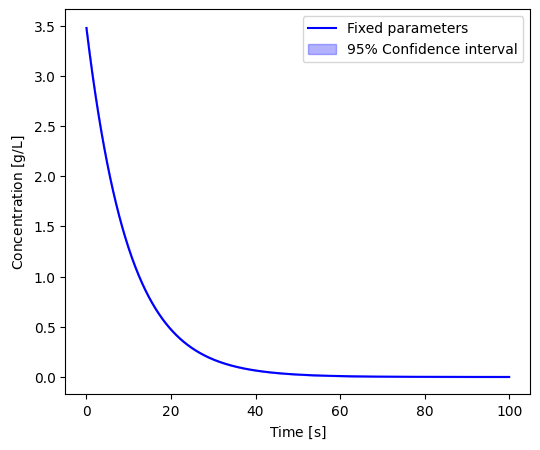

In [3]:
#Plotting the result
import matplotlib.pyplot as plt
time = np.linspace(t_start, t_final, n_steps)

plt.figure(figsize=(6, 5))
plt.plot(time, c_mean_op1, color = 'blue',label = 'Fixed parameters')
plt.fill_between(time, ci_lower_op1, ci_upper_op1, alpha=0.3, color = 'blue', label = "95% Confidence interval")
plt.legend()
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')
plt.show()


The concentration decays exponentially towards zero, with the confidence interval being smallest at the start and end of the simulation and largest near the "elbow" of the curve. A detailed comparison of both options is given in Task $5$.

### Task 5 - Monte Carlo Simulation with Time-Varying Parameters

In this task, the Monte Carlo simulation is repeated with parameters fluctuating at every time step. This is a achived by setting the Boolean value `fixed_parameters` to `False`, causing new values of $Q_{in} = Q_{out}$ to be resamples from the uniform distribution at each time step. 

In [4]:
#For task 5: Parameters vary at each time step
fixed_parameters = False

#Perform Monte Carlo simulation with same settings as Task 4
(c_mean_op2,
 c_std_op2,
 ci_lower_op2,
 ci_upper_op2
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, fixed_parameters)

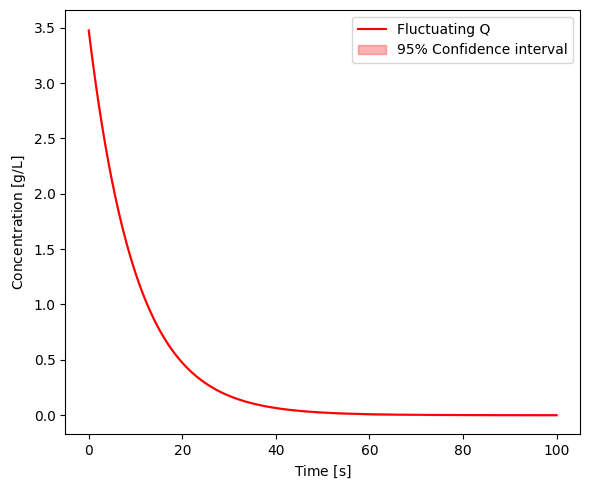

In [5]:
plt.figure(figsize=(6, 5))
plt.plot(time, c_mean_op2, color = 'red', label = 'Fluctuating Q')
plt.fill_between(time, ci_lower_op2, ci_upper_op2, alpha=0.3, color = 'red', label = "95% Confidence interval")
plt.legend()
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')
plt.tight_layout()
plt.show()

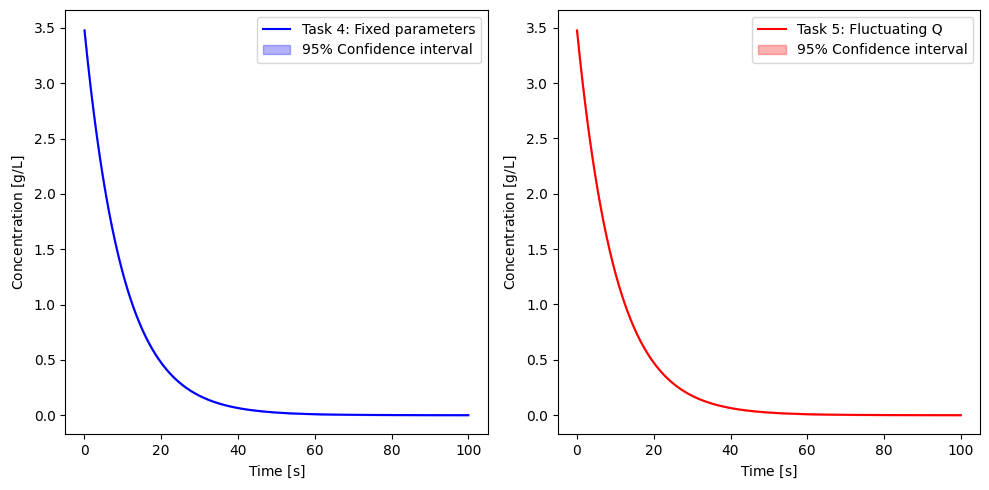

In [6]:
import matplotlib.pyplot as plt
time = np.linspace(t_start, t_final, n_steps)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(time, c_mean_op1, color = 'blue',label = 'Task 4: Fixed parameters')
plt.fill_between(time, ci_lower_op1, ci_upper_op1, alpha=0.3, color = 'blue', label = "95% Confidence interval")
plt.legend()
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')


plt.subplot(1, 2, 2)
plt.plot(time, c_mean_op2, color = 'red', label = 'Task 5: Fluctuating Q')
plt.fill_between(time, ci_lower_op2, ci_upper_op2, alpha=0.3, color = 'red', label = "95% Confidence interval")
plt.legend()
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')
plt.tight_layout()
plt.show()

In [7]:
width_op1 = ci_upper_op1 - ci_lower_op1
width_op2 = ci_upper_op2 - ci_lower_op2

mean_width_op1 = np.mean(width_op1)
mean_width_op2 = np.mean(width_op2)

print(f'Mean width option 1: {mean_width_op1:.7f}')
print(f'Mean width option 2: {mean_width_op2:.7f}')
print(f'Fixed parameters are {mean_width_op1/ mean_width_op2:.4f} times more uncertain')

Mean width option 1: 0.0061830
Mean width option 2: 0.0048097
Fixed parameters are 1.2855 times more uncertain


## Part 2: Three Interconnected Tanks with Parameter Uncertainty

In [8]:
import numpy as np
from numpy import random as rnd

r_seed = 18
rnd.seed(r_seed)
n_particles = 100
n_steps = 1000
dt = 0.1
concentration_1_history = np.zeros((n_particles, n_steps))
concentration_2_history = np.zeros((n_particles, n_steps))
concentration_3_history = np.zeros((n_particles, n_steps))

for run in range(n_particles):
    v = rnd.uniform(950, 1050)
    q_out = q_in = rnd.uniform(95, 105)
    c_in = 0.0
    c1 = rnd.uniform(3.4, 3.6)
    c2 = rnd.uniform(0, 0.1)
    c3 = rnd.uniform(0, 0.1)

    for t in range(n_steps):
        p = 1 - np.exp((-q_out / v) * dt)
        c1 = c1 * (1 - p) + c_in * p
        c2 = c2 * (1 - p) + c1 * p
        c3 = c3 * (1 - p) + c2 * p
        concentration_1_history[run, t] = c1
        concentration_2_history[run, t] = c2
        concentration_3_history[run, t] = c3

c_mean_1= np.mean(concentration_1_history, axis = 0)
c_std_1 = np.std(concentration_1_history, axis = 0)
ci_lower_1, ci_upper_1 = np.percentile(concentration_1_history, [2.5, 97.5], axis = 0)

c_mean_2= np.mean(concentration_2_history, axis = 0)
c_std_2 = np.std(concentration_2_history, axis = 0)
ci_lower_2, ci_upper_2 = np.percentile(concentration_2_history, [2.5, 97.5], axis = 0)

c_mean_3= np.mean(concentration_3_history, axis = 0)
c_std_3 = np.std(concentration_3_history, axis = 0)
ci_lower_3, ci_upper_3 = np.percentile(concentration_3_history, [2.5, 97.5], axis = 0)

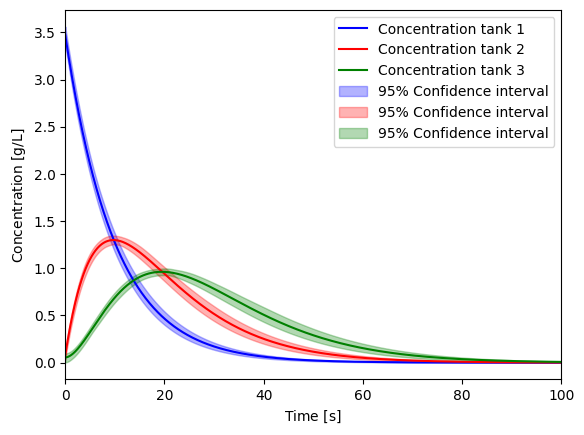

In [9]:
plt.plot(time, c_mean_1, color = 'blue', label = 'Concentration tank 1')
plt.plot(time, c_mean_2, color = 'red', label = 'Concentration tank 2')
plt.plot(time, c_mean_3, color = 'green', label = 'Concentration tank 3')
plt.fill_between(time, ci_lower_1, ci_upper_1, alpha=0.3, color = 'blue', label = "95% Confidence interval")
plt.fill_between(time, ci_lower_2, ci_upper_2, alpha=0.3, color = 'red', label = "95% Confidence interval")
plt.fill_between(time, ci_lower_3, ci_upper_3, alpha=0.3, color = 'green', label = "95% Confidence interval")
plt.legend()
plt.xlim(0,100)
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')
plt.show()

In [10]:
from ode_solver import ODESolver

def cd_2(r, t):
    ''' 3-tank system '''
    v = 1000
    q_in = q_out = 100
    c_in = 0.25
    c_1, c_2, c_3 = r
    rp = np.zeros(len(r))
    rp[0] = q_in/v * c_in - q_out/v * c_1 #Tank 1
    rp[1] = q_in/v * c_1 - q_out/v * c_2 #Tank 2
    rp[2] = q_in/v * c_2 - q_out/v * c_3 #Tank 3
    return rp

obj = ODESolver(cd_2, 0, 1000, 0.1, [3.5, 0, 0], 'rk4', adaptive = True)
t_res, r_res = obj.solve()

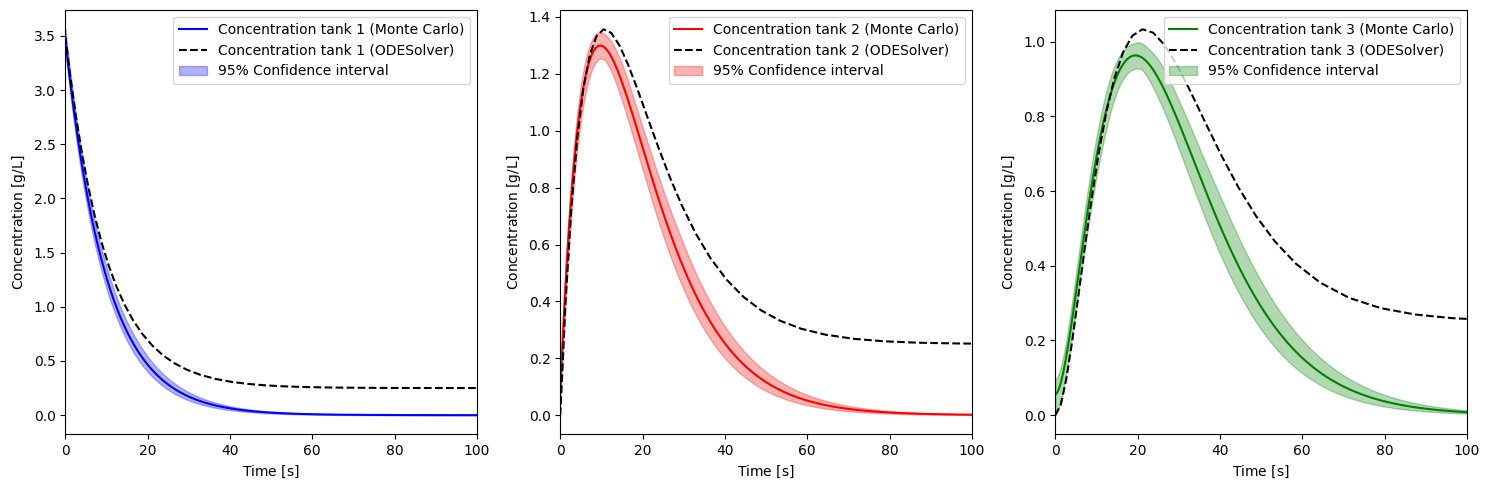

In [11]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(time, c_mean_1, color = 'blue', label = 'Concentration tank 1 (Monte Carlo)')
plt.plot(t_res, r_res[:, 0],'--', color = 'black', label = 'Concentration tank 1 (ODESolver)')
plt.fill_between(time, ci_lower_1, ci_upper_1, alpha=0.3, color = 'blue', label = "95% Confidence interval")
plt.legend()
plt.xlim(0,100)
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')


plt.subplot(1, 3, 2)
plt.plot(time, c_mean_2, color = 'red', label = 'Concentration tank 2 (Monte Carlo)')
plt.plot(t_res, r_res[:, 1],'--', color = 'black', label = 'Concentration tank 2 (ODESolver)')
plt.fill_between(time, ci_lower_2, ci_upper_2, alpha=0.3, color = 'red', label = "95% Confidence interval")
plt.legend()
plt.xlim(0,100)
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')


plt.subplot(1, 3, 3)
plt.plot(time, c_mean_3, color = 'green', label = 'Concentration tank 3 (Monte Carlo)')
plt.plot(t_res, r_res[:, 2],'--', color = 'black', label = 'Concentration tank 3 (ODESolver)')
plt.fill_between(time, ci_lower_3, ci_upper_3, alpha=0.3, color = 'green', label = "95% Confidence interval")
plt.legend()
plt.xlim(0,100)
plt.ylabel(r'Concentration $[\text{g/L}]$')
plt.xlabel(r'Time $[\text{s}]$')

plt.tight_layout()
plt.show()

# Exercise 2: Spreading of contaminants in underground aquifers using random walk

## Part 1: 2D Random Walk Model

### Task 1 - Something

In [12]:
import random
rnd.seed(18)
random.seed(18)

def random_walk_2d_basic(n_steps, start_pos = (1000, 1000), bounds = (0, 2000)):

    #Start position
    x, y = start_pos
    x_path = [x]
    y_path = [y]

    #Directions to choose from (dx, dy)
    north = (0, 1)
    south = (0, -1)
    east = (1, 0)
    west = (-1, 0)
    stay = (0, 0)

    directions = [north, south, east, west, stay]

    for _ in range(n_steps):

        #Choose a dicection at randon
        dx, dy = random.choice(directions)

        #Walk
        x += dx
        y += dy

        #Boundary check
        if not (bounds[0] <= x <= bounds[1] and bounds[0] <= y <= bounds[1]):
            break

        x_path.append(x)
        y_path.append(y)

    return x_path, y_path

In [13]:
n_steps = 1000
n_particles = 1000

side = int(np.sqrt(n_particles))  # 31 x 31 ≈ 1000
offset = side // 2

start_pos = [(1000 + i - offset, 1000 + j - offset)
             for i in range(side)
             for j in range(side)]

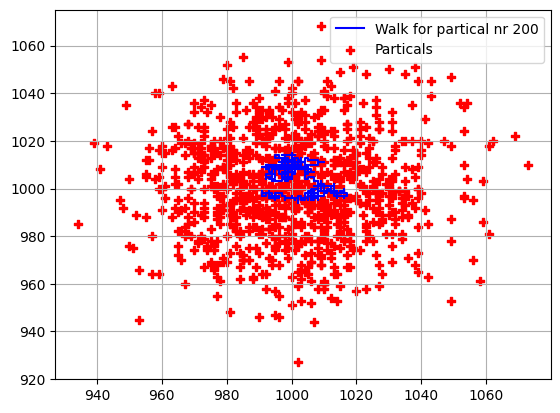

In [14]:
points = []
paths = []

n_steps = 1000
n_particles = 1000

for pos in start_pos:
    x_path, y_path = random_walk_2d_basic(n_steps, pos)
    paths.append((x_path, y_path))
    points.append((x_path[-1], y_path[-1]))

x_coords, y_coords = zip(*points)

#Path of partical 200
x_200, y_200 = paths[200]

#Plotting
plt.plot(x_200, y_200, '-', color = 'blue', label = 'Walk for partical nr 200')
plt.scatter(x_coords, y_coords, marker = 'P', color = 'red', label = 'Particals')
plt.legend()
plt.grid()
plt.show()

In [15]:
def random_walk_2d_weighted(n_steps, start_pos = (1000, 1000), bounds = (0, 2000)):

    #Start position
    x, y = start_pos
    x_path = [x]
    y_path = [y]

    #Directions to choose from (dx, dy)
    north = (0, 1)
    north_west = (-1, 1)
    north_east = (1, 1)
    south = (0, -1)
    south_west = (-1, -1)
    south_east = (1, -1)
    east = (1, 0)
    west = (-1, 0)
    stay = (0, 0)

    directions = [north,
                  north_west,
                  north_east,
                  south,
                  south_west,
                  south_east,
                  east,
                  west,
                  stay]

    probabilities = np.array([0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.2])

    #Make sure sum of prob is 1
    assert np.isclose(probabilities.sum(),1), 'Probabilities must sum to 1'

    for _ in range(n_steps):

        #Choose a dicection at randon
        dx, dy = random.choices(directions, weights = probabilities)[0]

        #Walk
        x += dx
        y += dy

        #Boundary check
        if not (bounds[0] <= x <= bounds[1] and bounds[0] <= y <= bounds[1]):
            break

        x_path.append(x)
        y_path.append(y)

    return x_path, y_path

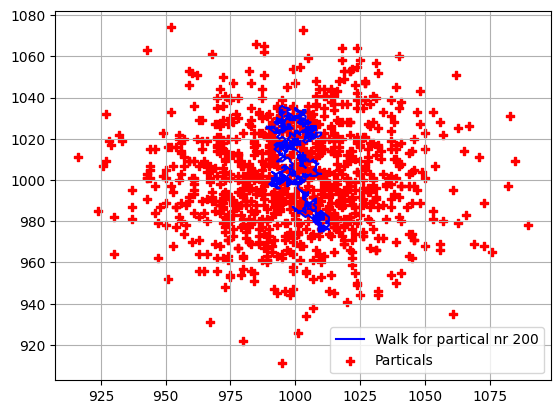

In [16]:
points = []
paths = []

n_steps = 1000
n_particles = 1000

for pos in start_pos:
    x_path, y_path = random_walk_2d_weighted(n_steps, pos)
    paths.append((x_path, y_path))
    points.append((x_path[-1], y_path[-1]))

x_coords, y_coords = zip(*points)

#Path of partical 200
x_200, y_200 = paths[200]

#Plotting
plt.plot(x_200, y_200, '-', color = 'blue', label = 'Walk for partical nr 200')
plt.scatter(x_coords, y_coords, marker = 'P', color = 'red', label = 'Particals')
plt.legend()
plt.grid()
plt.show()

## Part 2: 2D Random Walk Model of Contaminant Transport in Aquifers

### Task 1

In [17]:
source = (1000, 1000)

### Task 2

In [18]:
distance_m = 10_000 #meters
migration_rate = 10 #meters/year

minimum_time = distance_m / migration_rate #years

print(f'The minimum time required for the contaminant to reach 10 km is {minimum_time} years')

The minimum time required for the contaminant to reach 10 km is 1000.0 years


### Task 3

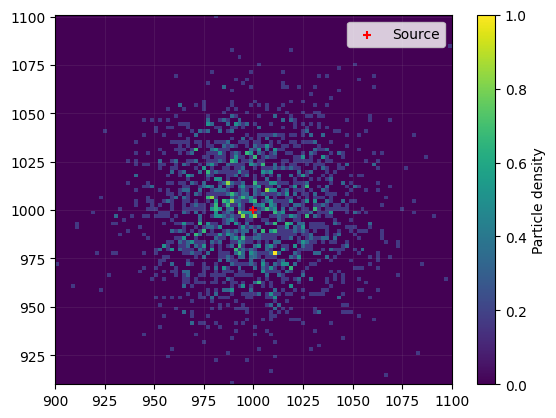

In [19]:
n_particles = 2000
n_steps = 2000

final_pos = []

for i in range(n_particles):
    x_path, y_path = random_walk_2d_basic(n_steps, source)
    final_pos.append((x_path[-1], y_path[-1]))

final_pos_x, final_pos_y = zip(*final_pos)

#Plotting
plt.hist2d(final_pos_x, final_pos_y, bins=100)
plt.scatter(1000, 1000, color='red', marker='+', label='Source')
plt.colorbar(label="Particle density")
plt.legend()
plt.grid(alpha = 0.1)
plt.show()

### Task 4

In [20]:
random.seed(67)
def time_to_reach_distance_unbiased(distance_to_reach = 1000, start_pos = (1000, 1000)):
    years = 0

    #To improve computational speed
    distance_to_reach = distance_to_reach**2

    #Start position
    x, y = start_pos

    #Directions to choose from (dx, dy)
    north = (0, 1)
    south = (0, -1)
    east = (1, 0)
    west = (-1, 0)

    directions = [north, south, east, west]

    while True:
        #Choose a dicection at randon
        dx, dy = random.choice(directions)

        #Walk
        x += dx
        y += dy

        #Steps
        years += 1

        #See if distance is reached
        distance =(x - start_pos[0])**2 + (y - start_pos[1])**2
        if distance >= distance_to_reach:
            return years


In [21]:
arrival_times_unbiased = []

n_runs = 100

for i in range(n_runs):
    arrival_times_unbiased.append(time_to_reach_distance_unbiased(1000, (1000, 1000)))

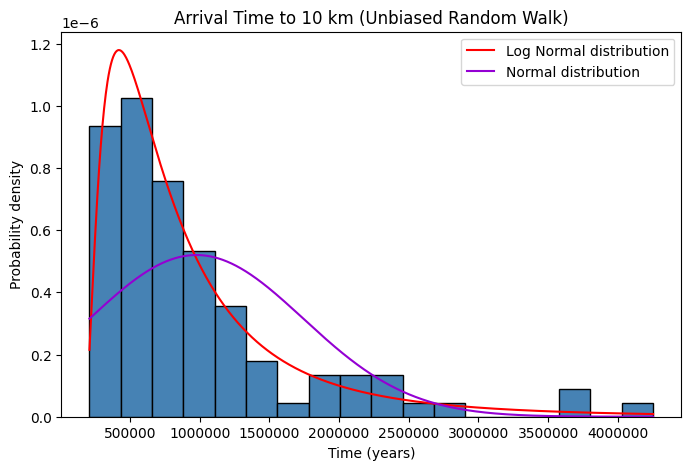

In [22]:
import scipy.stats as stats
arrival_times_unbiased = np.array(arrival_times_unbiased)
shape, loc, scale = stats.lognorm.fit(arrival_times_unbiased)
mu, sigma = arrival_times_unbiased.mean(), arrival_times_unbiased.std()
x = np.linspace(min(arrival_times_unbiased), max(arrival_times_unbiased), 1000)

plt.figure(figsize=(8, 5))
plt.hist(arrival_times_unbiased, bins=18,density=True, edgecolor='black', color = 'steelblue')
plt.title('Arrival Time to 10 km (Unbiased Random Walk)')
plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale), color = 'red', label = 'Log Normal distribution')
plt.plot(x, stats.norm.pdf(x, mu, sigma), color = 'darkviolet', label = 'Normal distribution')
plt.xlabel('Time (years)')
plt.ylabel('Probability density')
plt.legend()
plt.ticklabel_format(style='plain', axis='x')
plt.show()


### Task 5

In [23]:
random.seed(18)
def time_to_reach_distance_biased(distance_to_reach = 1000, start_pos = (1000, 1000)):
    years = 0

    #Start position
    x, y = start_pos

    #Directions to choose from (dx, dy)
    north = (0, 1)
    south = (0, -1)
    east = (1, 0)
    west = (-1, 0)

    directions = [north, south, east, west]

    probabilities = np.array([0.2,
                              0.4,
                              0.2,
                              0.2])

    #Make sure sum of prob is 1
    assert np.isclose(probabilities.sum(),1), 'Probabilities must sum to 1'

    while True:
        #Choose a dicection at randon
        dx, dy = random.choices(directions, weights = probabilities)[0]

        #Walk
        x += dx
        y += dy

        #Steps
        years += 1

        #See if distance is reached
        target_y = start_pos[1] - distance_to_reach
        if y <= target_y:
            return years


In [24]:
arrival_times_biased = []

n_runs = 100

for i in range(n_runs):
    arrival_times_biased.append(time_to_reach_distance_biased(1000, (1000, 1000)))

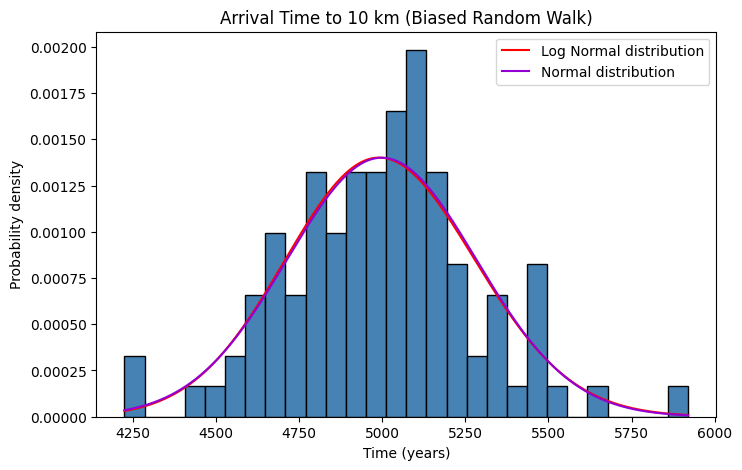

In [25]:
arrival_times_biased = np.array(arrival_times_biased)
shape, loc, scale = stats.lognorm.fit(arrival_times_biased)
mu, sigma = arrival_times_biased.mean(), arrival_times_biased.std()
x = np.linspace(min(arrival_times_biased), max(arrival_times_biased), 1000)

plt.figure(figsize=(8, 5))
plt.hist(arrival_times_biased, bins=28,density=True, edgecolor='black', color = 'steelblue')
plt.title('Arrival Time to 10 km (Biased Random Walk)')
plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale), color = 'red', label = 'Log Normal distribution')
plt.plot(x, stats.norm.pdf(x, mu, sigma), color = 'darkviolet', label = 'Normal distribution')
plt.xlabel('Time (years)')
plt.ylabel('Probability density')
plt.legend()
plt.ticklabel_format(style='plain', axis='x')
plt.show()